## FlightDelays
	--- FLIGHT DELAY CLASSIFICATION PROJECT ---
	Date: November 04, 2025
	Dataset: flight_delay.csv

In [37]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt 
import seaborn as sns 
import logging
import warnings
import statistics
warnings.filterwarnings('ignore')

# Logging
	Make the logging to show the Error 

In [38]:
logger = logging.getLogger(__name__)

## Load Data
	

In [39]:
df = pd.read_csv(r'../../data/FlightDelays.csv')

In [40]:
df.shape

(1319, 7)

In [41]:
df.head()

,Binned_CRS_DEP_TIME,CARRIER,DEST,ORIGIN,Weather,DAY_WEEK,Flight Status
0,5,DH,LGA,IAD,0,5,Delayed
1,3,DH,LGA,IAD,0,5,Delayed
2,8,DH,JFK,IAD,0,5,Delayed
3,4,DH,EWR,IAD,0,5,Delayed
4,5,DH,EWR,IAD,0,5,Delayed


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Binned_CRS_DEP_TIME  1319 non-null   int64 
 1   CARRIER              1319 non-null   object
 2   DEST                 1319 non-null   object
 3   ORIGIN               1319 non-null   object
 4   Weather              1319 non-null   int64 
 5   DAY_WEEK             1319 non-null   int64 
 6   Flight Status        1319 non-null   object
dtypes: int64(3), object(4)
memory usage: 72.3+ KB


In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Binned_CRS_DEP_TIME,1319.0,4.580743,2.129201,1.0,3.0,5.0,6.0,8.0
Weather,1319.0,0.024261,0.153916,0.0,0.0,0.0,0.0,1.0
DAY_WEEK,1319.0,3.977255,1.895069,1.0,2.0,4.0,5.0,7.0


<Axes: >

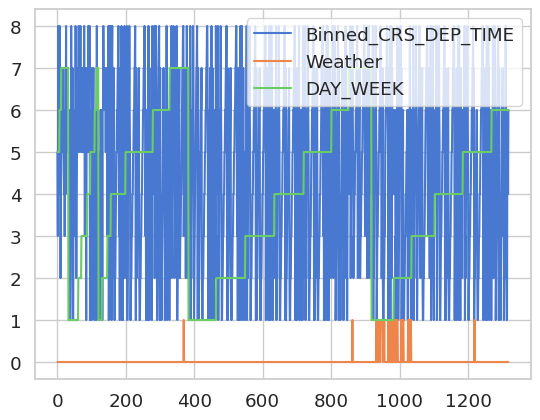

In [44]:
df.plot()

## Drop Weather 

In [45]:
if 'Weather' in df.columns:
    df = df.drop('Weather', axis=1)
    print("\n'Weather' column dropped.")
else:
    print("\n'Weather' column not found.")
      


'Weather' column dropped.


In [47]:
df.head()

,Binned_CRS_DEP_TIME,CARRIER,DEST,ORIGIN,DAY_WEEK,Flight Status
0,5,DH,LGA,IAD,5,Delayed
1,3,DH,LGA,IAD,5,Delayed
2,8,DH,JFK,IAD,5,Delayed
3,4,DH,EWR,IAD,5,Delayed
4,5,DH,EWR,IAD,5,Delayed


## Target Variable
	-- Assume the target is 'Delay' or 'Delayed'